# 🎓 Placement Model Training Notebook

### AI Resume Analyzer & Placement Prediction System

This notebook trains the machine learning model that powers the Streamlit
application in this project. It takes a dataset of engineering student
profiles (academics, skills, internships, projects, lifestyle factors, etc.)
and trains a classifier to predict **placement outcome** (`Placed` /
`Not Placed`).

**To use your own data:** replace `data/placement_data.csv` with a CSV that
has the same column names, then re-run this notebook top to bottom (`Kernel
→ Restart & Run All`). Everything downstream — cleaning, encoding, model
training, evaluation, and the exported artifacts the Streamlit app depends
on — will regenerate automatically.

## Table of Contents
1. Import Libraries
2. Load Dataset
3. Understand the Dataset
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Encoding Categorical Variables
8. Feature Scaling
9. Train-Test Split
10. Building the Preprocessing + Modeling Pipeline
11. Train Multiple Models
12. Model Comparison
13. Select Best Model
14. Hyperparameter Tuning
15. Confusion Matrix
16. ROC Curve
17. Classification Report
18. Cross-Validation
19. Feature Importance
20. Save the Final Model & Supporting Artifacts
21. Sanity Check — Predict a Sample Student
22. Conclusion

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
)

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Make the shared `utils` package (project root) importable so this notebook
# uses the EXACT SAME feature-engineering code the Streamlit app uses --
# one formula, defined once, so training and serving can never drift apart.
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.feature_engineering import PlacementFeatureEngineer


def to_serializable(obj):
    """Recursively convert numpy/pandas types to plain Python types so
    json.dump never chokes on them (a very common gotcha with sklearn +
    numpy outputs)."""
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


# ---- Consistent, print-friendly plotting style for this notebook ----
sns.set_theme(style="whitegrid")
ACCENT = "#1d4ed8"       # primary blue accent used across all charts
ACCENT_DARK = "#1e3a8a"
PALETTE = {"Placed": "#1d4ed8", "Not Placed": "#f59e0b"}
mpl.rcParams["figure.dpi"] = 130
mpl.rcParams["savefig.dpi"] = 150
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["axes.titleweight"] = "bold"

REPORTS_DIR = Path("../reports")
MODELS_DIR = Path("../models")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries imported successfully.")
print(f"Project root added to sys.path: {PROJECT_ROOT}")

Libraries imported successfully.
Project root added to sys.path: /home/claude/build/placement-ai-suite


## 2. Load Dataset

The notebook checks a few likely locations for the CSV so it keeps working
whether you run it from the `notebooks/` folder (the default) or from the
project root. **To use a different dataset, just replace
`data/placement_data.csv`** with a CSV that has the same column names.

In [2]:
CANDIDATE_PATHS = [
    Path("../data/placement_data.csv"),
    Path("data/placement_data.csv"),
    Path("placement_data.csv"),
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find placement_data.csv. Checked: "
        + ", ".join(str(p) for p in CANDIDATE_PATHS)
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH.resolve()}")
df.head()

Loaded dataset from: /home/claude/build/placement-ai-suite/data/placement_data.csv


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


## 3. Understand the Dataset

### 3.1 Shape — how many students and how many columns?

In [3]:
print(f"The dataset contains {df.shape[0]:,} students and {df.shape[1]} columns.")
df.shape

The dataset contains 5,000 students and 25 columns.


(5000, 25)

### 3.2 Column Names

In [4]:
print("Columns in the dataset:\n")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2d}. {col}")

Columns in the dataset:

 1. Student_ID
 2. gender
 3. branch
 4. cgpa
 5. tenth_percentage
 6. twelfth_percentage
 7. backlogs
 8. study_hours_per_day
 9. attendance_percentage
10. projects_completed
11. internships_completed
12. coding_skill_rating
13. communication_skill_rating
14. aptitude_skill_rating
15. hackathons_participated
16. certifications_count
17. sleep_hours
18. stress_level
19. part_time_job
20. family_income_level
21. city_tier
22. internet_access
23. extracurricular_involvement
24. placement_status
25. salary_lpa


### 3.3 Preview — First and Last Rows

In [5]:
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [6]:
df.tail()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,2,7.3,2,No,Medium,Tier 3,Yes,Low,Placed,19.35
4996,4997,Male,IT,7.76,74.3,72.6,2,6.3,72.3,4,...,2,7.8,6,No,Low,Tier 1,Yes,Low,Not Placed,0.00
4997,4998,Male,IT,7.79,64.0,71.2,2,2.0,63.8,6,...,2,6.1,5,Yes,Low,Tier 2,No,Medium,Placed,19.13
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,5,9.0,10,No,Medium,Tier 2,Yes,High,Placed,16.53
4999,5000,Male,CSE,9.45,85.6,80.0,0,2.8,63.4,8,...,2,7.8,1,No,Low,Tier 1,No,High,Placed,20.00


### 3.4 Statistical Summary

In [7]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
Student_ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.50,3750.2500,5000.0
cgpa,5000.0,8.283798,1.008391,5.0,7.61,8.32,9.0200,10.0
tenth_percentage,5000.0,74.537400,10.266752,50.0,67.40,74.70,82.0000,100.0
twelfth_percentage,5000.0,74.543060,10.244481,50.0,67.60,74.80,81.7000,100.0
backlogs,5000.0,0.343600,0.612547,0.0,0.00,0.00,1.0000,5.0
study_hours_per_day,5000.0,4.041120,1.967754,0.0,2.70,4.00,5.4000,10.0
attendance_percentage,5000.0,72.041560,7.720029,44.7,66.60,72.05,77.2000,99.2
projects_completed,5000.0,5.529400,2.053772,0.0,4.00,6.00,7.0000,8.0
internships_completed,5000.0,2.132600,1.143713,0.0,1.00,2.00,3.0000,4.0
coding_skill_rating,5000.0,3.728600,1.278464,1.0,3.00,4.00,5.0000,5.0


In [8]:
df.describe(include="object").T

,count,unique,top,freq
gender,5000,2,Male,2999
branch,5000,5,CSE,1522
part_time_job,5000,2,No,4007
family_income_level,5000,3,Medium,2466
city_tier,5000,3,Tier 2,2023
internet_access,5000,2,Yes,4461
extracurricular_involvement,3994,3,Medium,1501
placement_status,5000,2,Placed,4303


### 3.5 Data Types & Non-Null Counts

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   str    
 2   branch                       5000 non-null   str    
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rating        

### 3.6 Missing Values

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)
print(f"Columns with missing values: {len(missing_report)} out of {df.shape[1]}")
missing_report

Columns with missing values: 1 out of 25


,missing_count,missing_pct
extracurricular_involvement,1006,20.12


### 3.7 Duplicate Rows

In [11]:
n_dupes = df.duplicated().sum()
n_dupe_ids = df["Student_ID"].duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")
print(f"Duplicate Student_ID values: {n_dupe_ids}")

Fully duplicated rows: 0
Duplicate Student_ID values: 0


## 4. Data Cleaning

Three things need attention before modeling:

1. **`Student_ID`** is a unique row identifier with no predictive value — drop it.
2. **`extracurricular_involvement`** is missing for roughly 20% of students.
   Rather than guessing a level, we keep that fact visible as its own
   category (`"Unknown"`) — *not stating* an activity level could itself be
   informative, and silently imputing a guess would hide that.
3. **`placement_status`** (currently the text `"Placed"` / `"Not Placed"`) is
   mapped to a binary `1` / `0` target that scikit-learn can work with.

**Note on `salary_lpa`:** this column is exactly `0` for every student who
was *not* placed, and only takes a real value for students who *were*
placed — it is a **consequence** of the outcome we're trying to predict, not
a cause of it. Using it as a model input would leak the answer, so it is
kept only for one exploratory chart below (average salary by branch) and is
explicitly excluded before we build `X`.

In [12]:
df_clean = df.copy()

# 1) Drop the identifier column.
df_clean = df_clean.drop(columns=["Student_ID"])

# 2) Preserve missingness as its own category instead of guessing a level.
df_clean["extracurricular_involvement"] = df_clean["extracurricular_involvement"].fillna("Unknown")

# 3) Binary-encode the target: Placed = 1, Not Placed = 0.
df_clean["placement_status"] = df_clean["placement_status"].map({"Placed": 1, "Not Placed": 0})
df_clean["placement_label"] = df_clean["placement_status"].map({1: "Placed", 0: "Not Placed"})

# 4) Drop exact duplicate rows, if any.
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate row(s).")

print(f"Remaining missing values: {df_clean.isnull().sum().sum()} total missing cells")
df_clean.head()

Dropped 0 duplicate row(s).
Remaining missing values: 0 total missing cells


,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa,placement_label
0,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,...,6.5,8,Yes,Medium,Tier 2,Yes,Medium,1,14.95,Placed
1,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,...,7.1,8,Yes,Medium,Tier 3,Yes,Low,1,14.91,Placed
2,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,...,6.1,2,No,Low,Tier 2,Yes,High,1,17.73,Placed
3,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,...,7.3,7,No,Medium,Tier 1,Yes,Low,1,14.52,Placed
4,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,...,6.0,7,No,Medium,Tier 1,Yes,Medium,1,15.91,Placed


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Distribution — how imbalanced is the dataset?

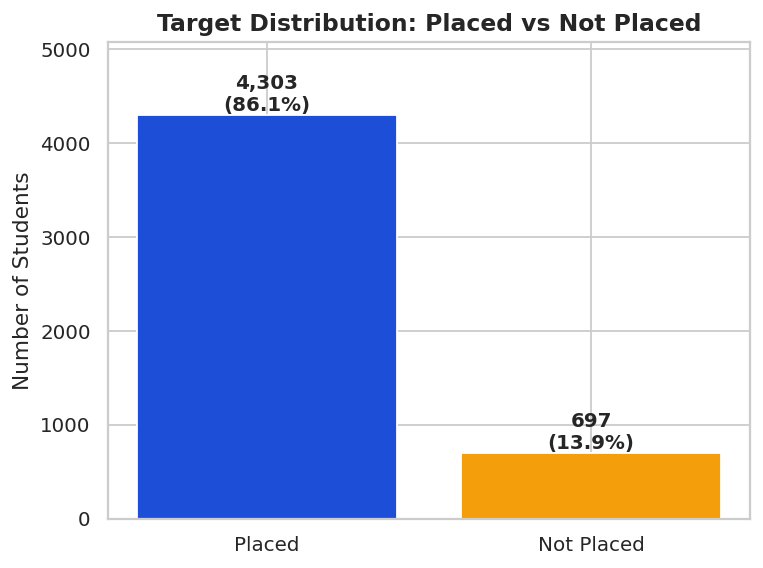

Placed: 4,303 (86.1%)  |  Not Placed: 697 (13.9%)
The dataset is imbalanced, so raw accuracy alone would be misleading -- a model
that always predicts 'Placed' would already score about 86% accuracy
without learning anything. We account for this later when choosing our evaluation metric.


In [13]:
order = ["Placed", "Not Placed"]
status_counts = df_clean["placement_label"].value_counts().reindex(order)
status_pct = (status_counts / status_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(order, status_counts.values, color=[PALETTE[o] for o in order])
for bar, pct, cnt in zip(bars, status_pct.values, status_counts.values):
    ax.annotate(f"{cnt:,.0f}\n({pct}%)", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Target Distribution: Placed vs Not Placed")
ax.set_ylabel("Number of Students")
ax.set_ylim(0, status_counts.max() * 1.18)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "target_distribution.png", bbox_inches="tight")
plt.show()

print(f"Placed: {status_counts['Placed']:,} ({status_pct['Placed']}%)  |  "
      f"Not Placed: {status_counts['Not Placed']:,} ({status_pct['Not Placed']}%)")
print("The dataset is imbalanced, so raw accuracy alone would be misleading -- a model")
print(f"that always predicts 'Placed' would already score about {status_pct['Placed']:.0f}% accuracy")
print("without learning anything. We account for this later when choosing our evaluation metric.")

### 5.2 Histogram — CGPA Distribution

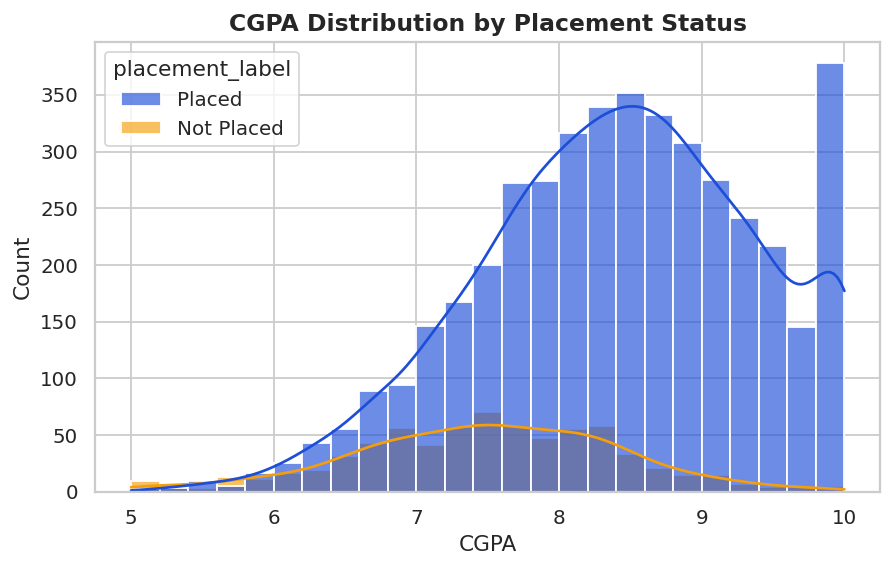

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df_clean, x="cgpa", hue="placement_label", bins=25, kde=True,
             palette=PALETTE, hue_order=order, ax=ax, alpha=0.65)
ax.set_title("CGPA Distribution by Placement Status")
ax.set_xlabel("CGPA")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "hist_cgpa.png", bbox_inches="tight")
plt.show()

### 5.3 Feature Distributions — All Numeric Features

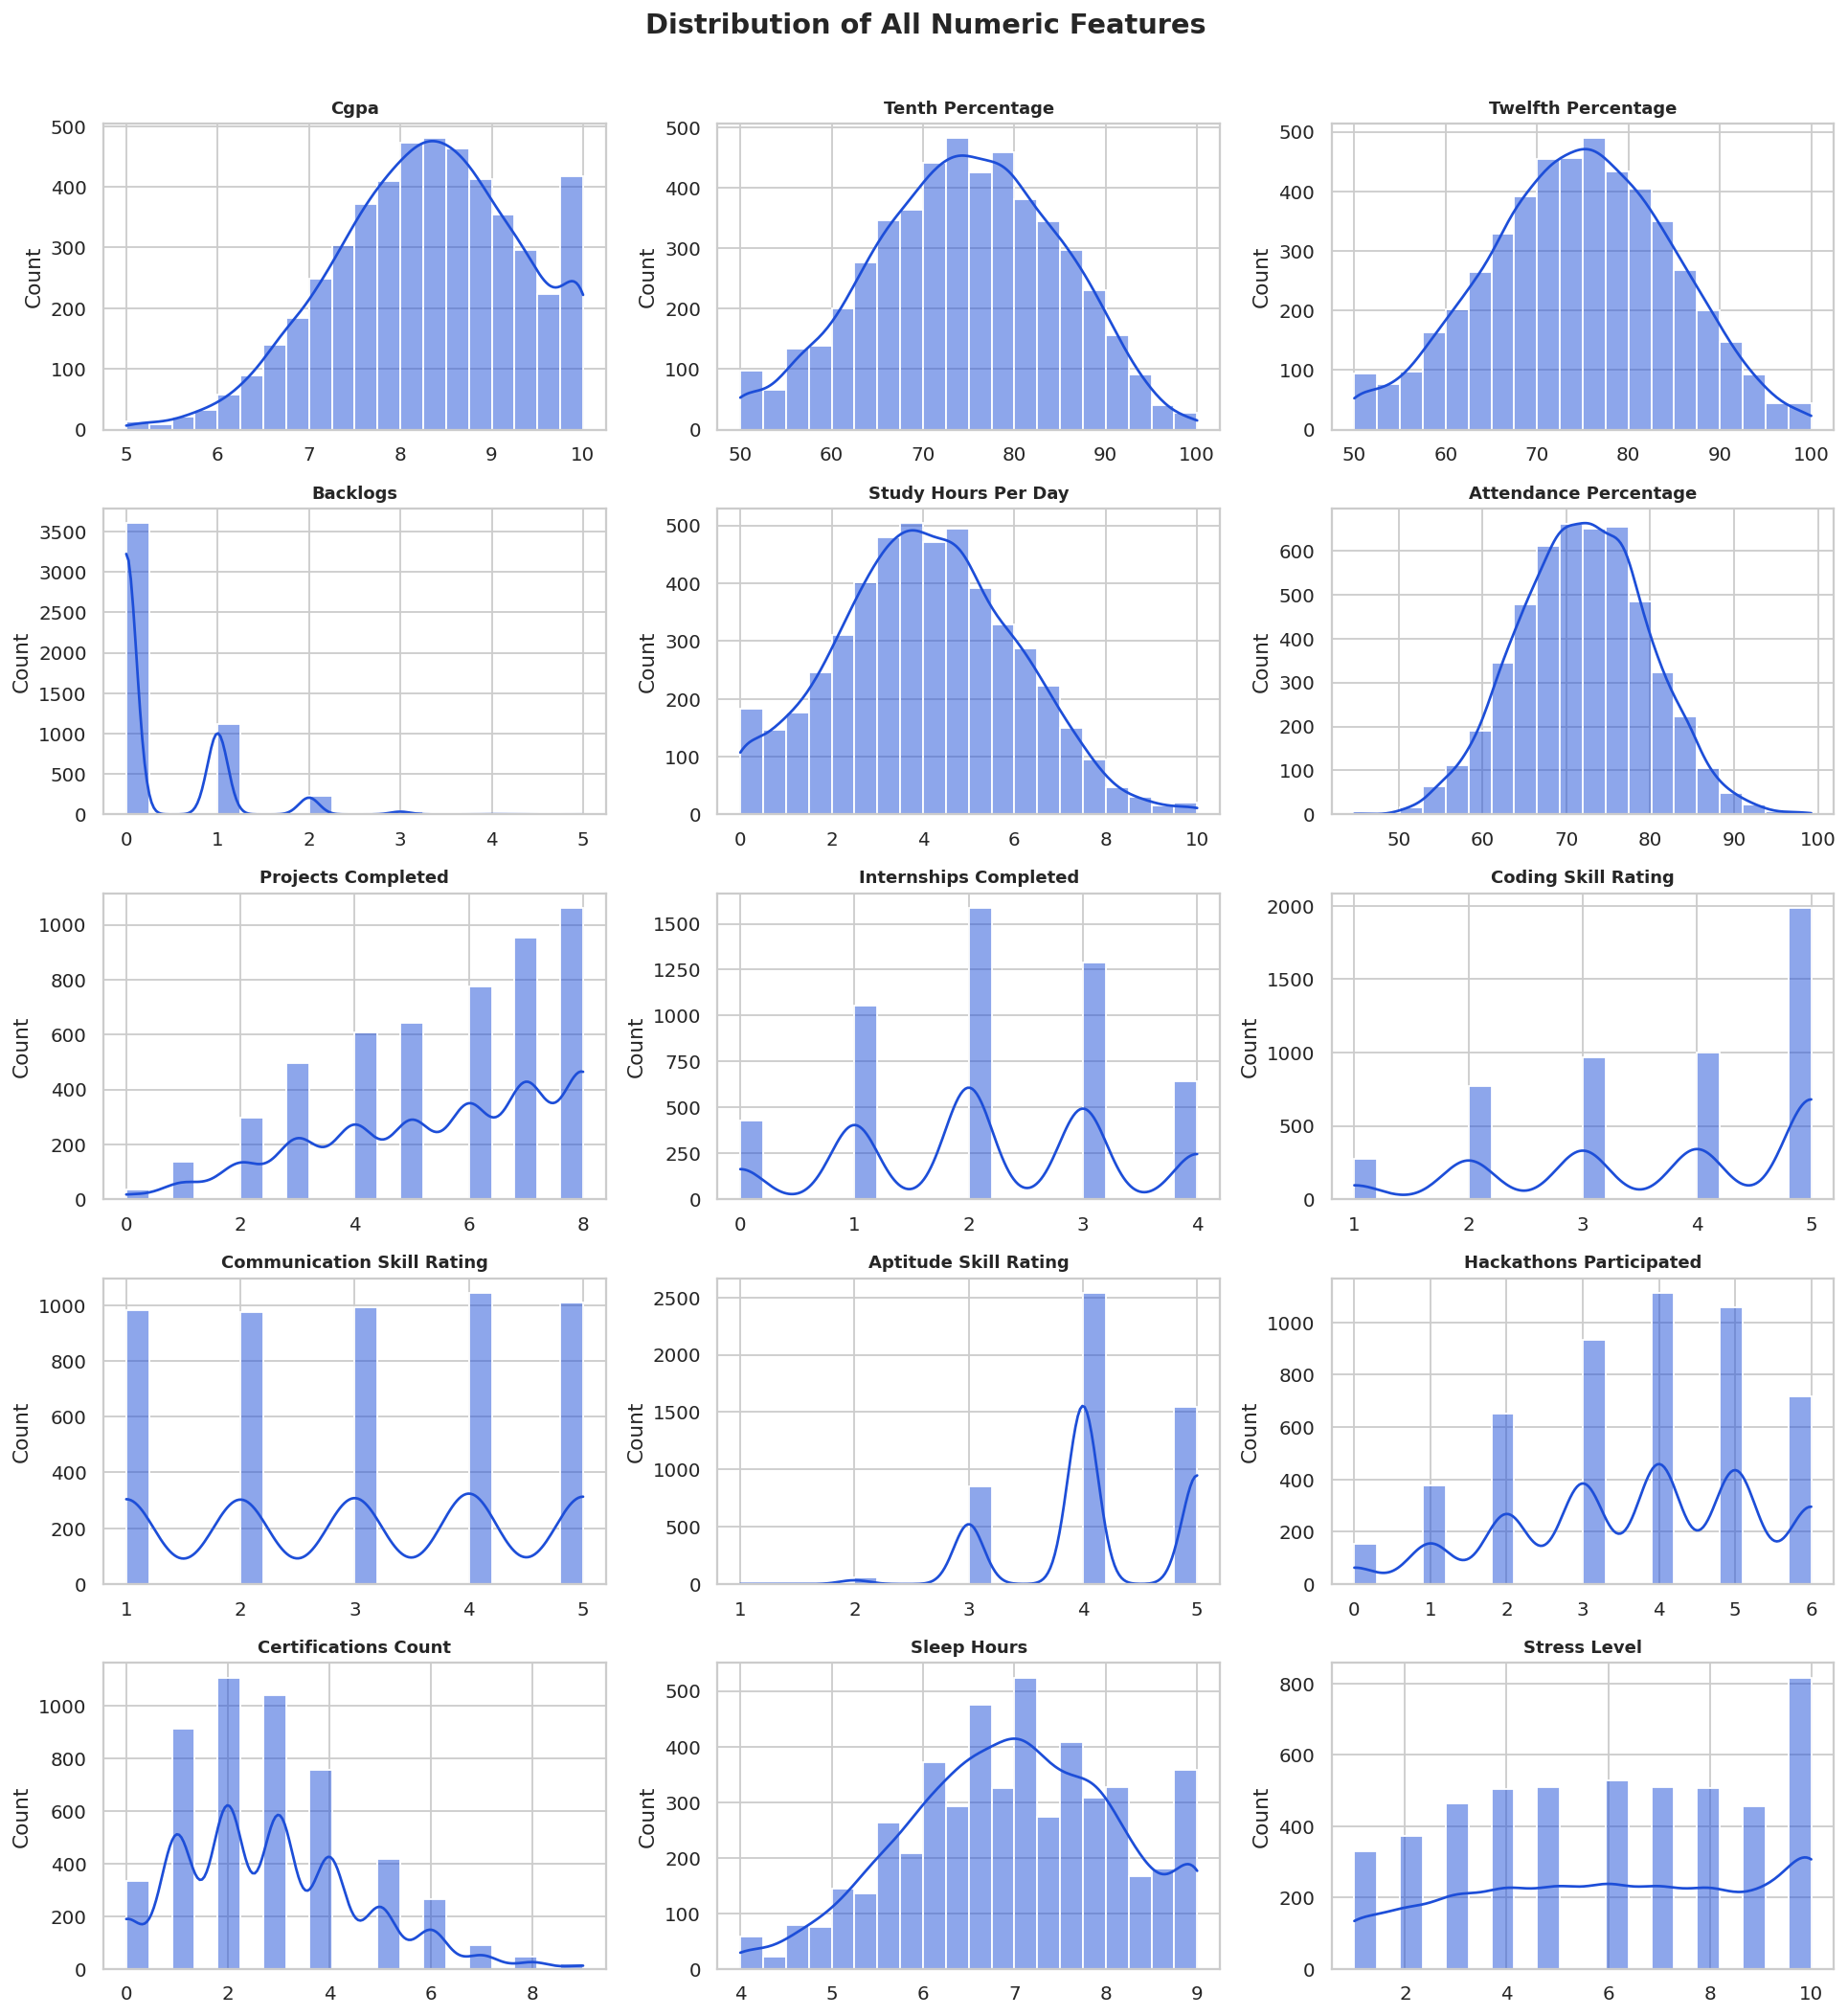

In [15]:
numeric_cols_raw = [
    "cgpa", "tenth_percentage", "twelfth_percentage", "backlogs",
    "study_hours_per_day", "attendance_percentage", "projects_completed",
    "internships_completed", "coding_skill_rating", "communication_skill_rating",
    "aptitude_skill_rating", "hackathons_participated", "certifications_count",
    "sleep_hours", "stress_level",
]

fig, axes = plt.subplots(5, 3, figsize=(15, 16))
for ax, col in zip(axes.flatten(), numeric_cols_raw):
    sns.histplot(df_clean[col], bins=20, color=ACCENT, kde=True, ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribution of All Numeric Features", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "feature_distributions.png", bbox_inches="tight")
plt.show()

### 5.4 Countplot — Branch vs Placement

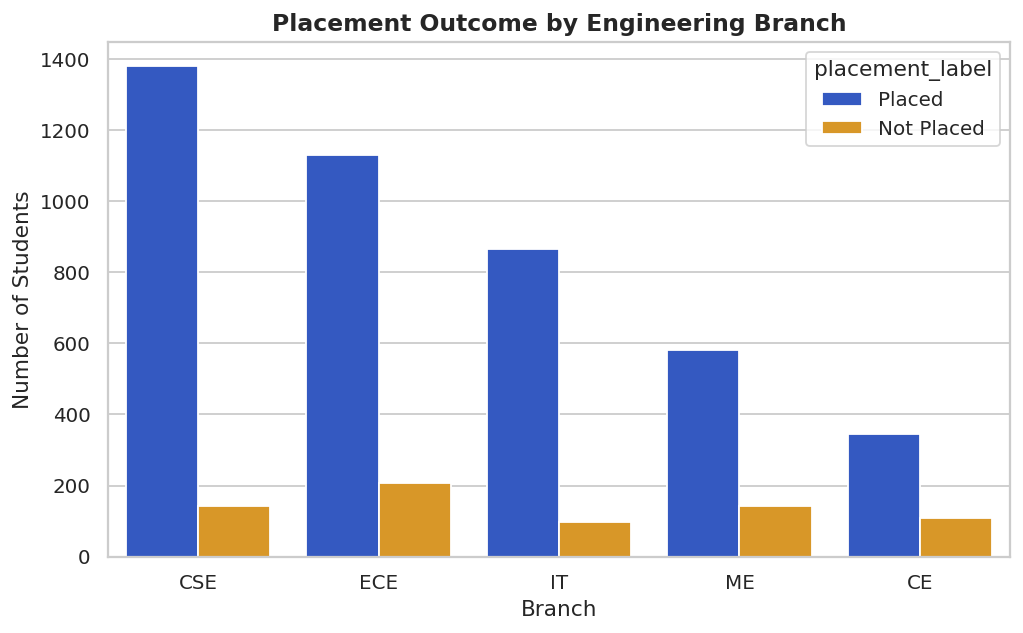

Placement rate by branch:
branch
CSE    90.7%
IT     89.8%
ECE    84.6%
ME     80.3%
CE     76.2%


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_clean, x="branch", hue="placement_label", palette=PALETTE,
              hue_order=order, ax=ax, order=df_clean["branch"].value_counts().index)
ax.set_title("Placement Outcome by Engineering Branch")
ax.set_xlabel("Branch")
ax.set_ylabel("Number of Students")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "countplot_branch.png", bbox_inches="tight")
plt.show()

placement_rate_by_branch = (df_clean.groupby("branch")["placement_status"].mean().sort_values(ascending=False) * 100)
print("Placement rate by branch:")
print((placement_rate_by_branch.round(1).astype(str) + "%").to_string())

### 5.5 Correlation Matrix & Heatmap

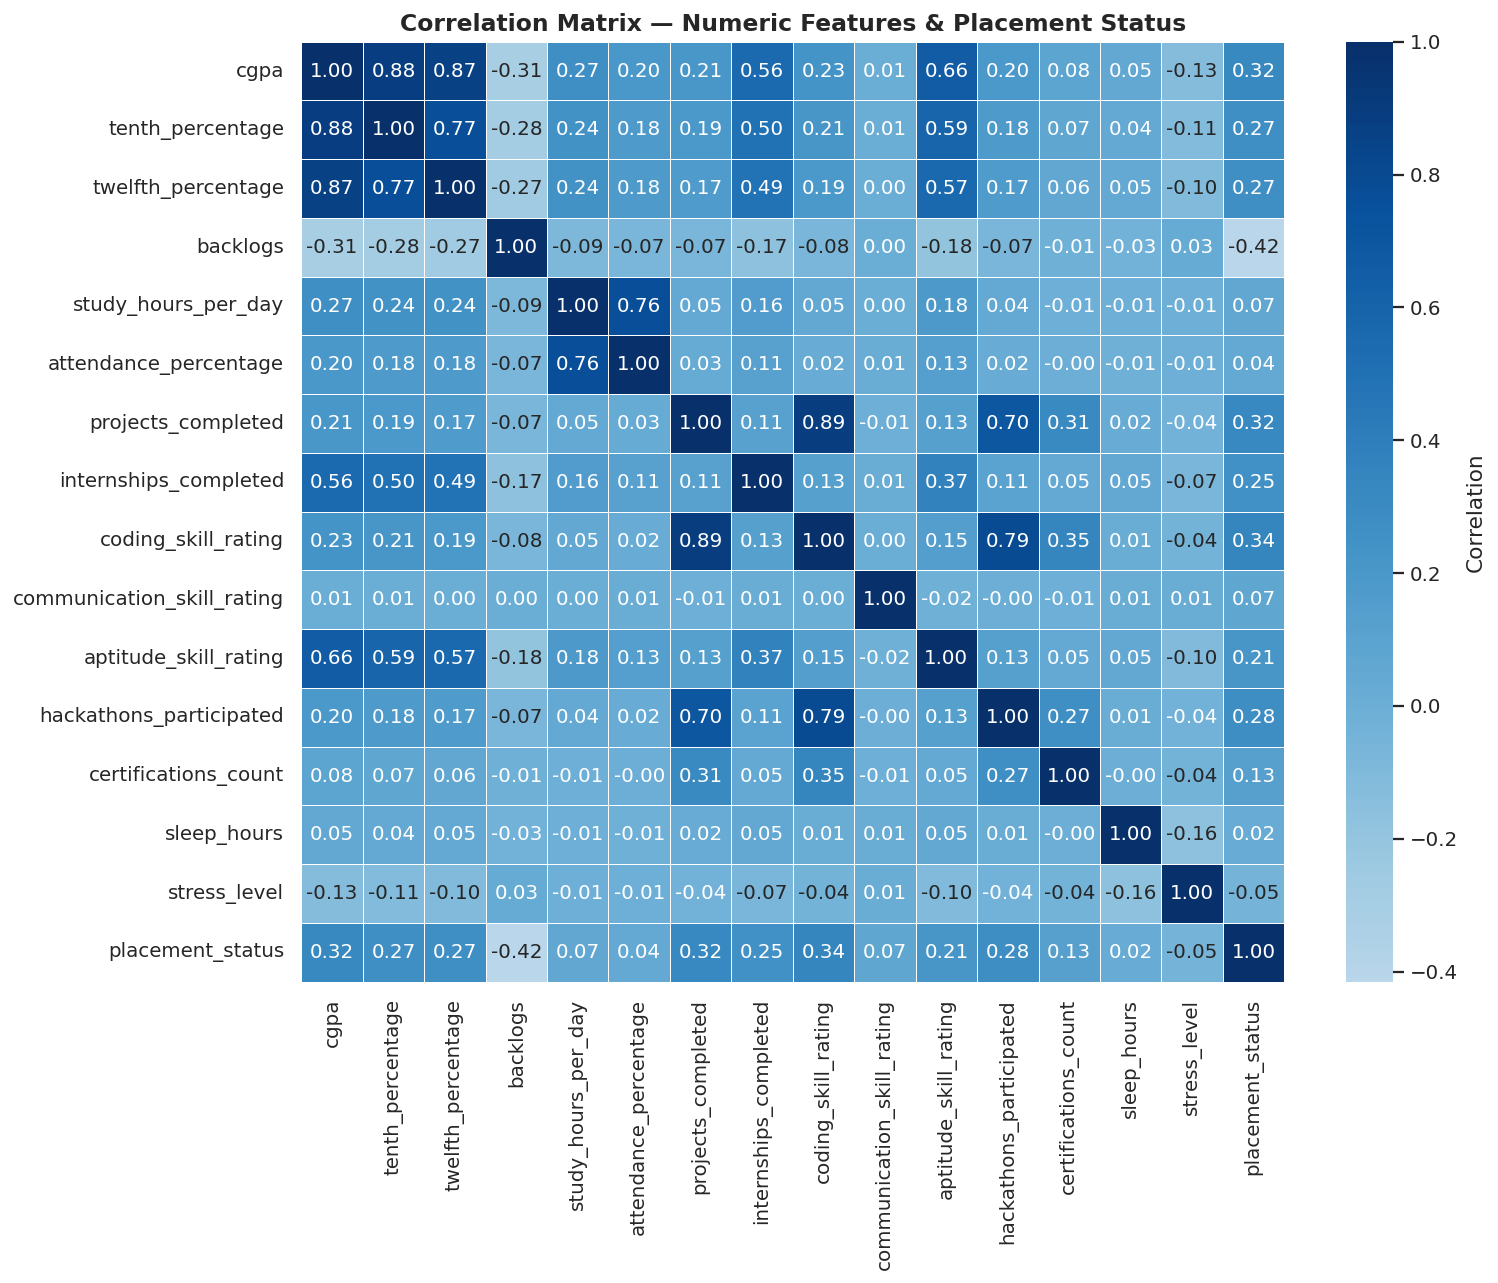

Features most correlated with placement status:
coding_skill_rating           0.343
projects_completed            0.323
cgpa                          0.316
hackathons_participated       0.276
tenth_percentage              0.270
twelfth_percentage            0.268
internships_completed         0.254
aptitude_skill_rating         0.214
certifications_count          0.126
communication_skill_rating    0.075
study_hours_per_day           0.065
attendance_percentage         0.042
sleep_hours                   0.016
stress_level                 -0.046
backlogs                     -0.415


In [17]:
corr_cols = numeric_cols_raw + ["placement_status"]
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Matrix — Numeric Features & Placement Status")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

target_corr = corr_matrix["placement_status"].drop("placement_status").sort_values(ascending=False)
print("Features most correlated with placement status:")
print(target_corr.round(3).to_string())

### 5.6 Placement Rate Heatmap — Branch × City Tier

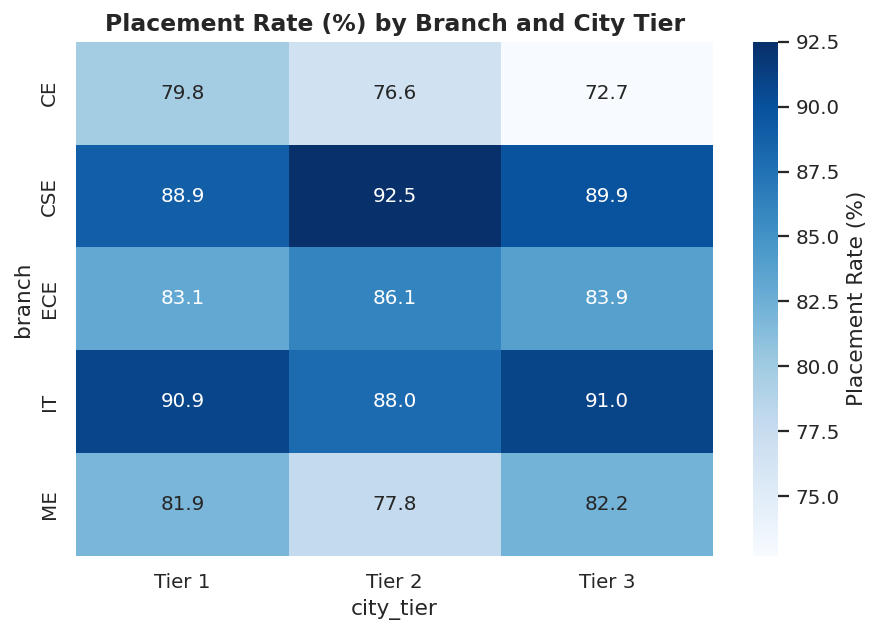

In [18]:
pivot = df_clean.pivot_table(values="placement_status", index="branch", columns="city_tier", aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot.round(1), annot=True, fmt=".1f", cmap="Blues", ax=ax,
            cbar_kws={"label": "Placement Rate (%)"})
ax.set_title("Placement Rate (%) by Branch and City Tier")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "placement_rate_heatmap.png", bbox_inches="tight")
plt.show()

### 5.7 CGPA by Placement Status — Boxplot

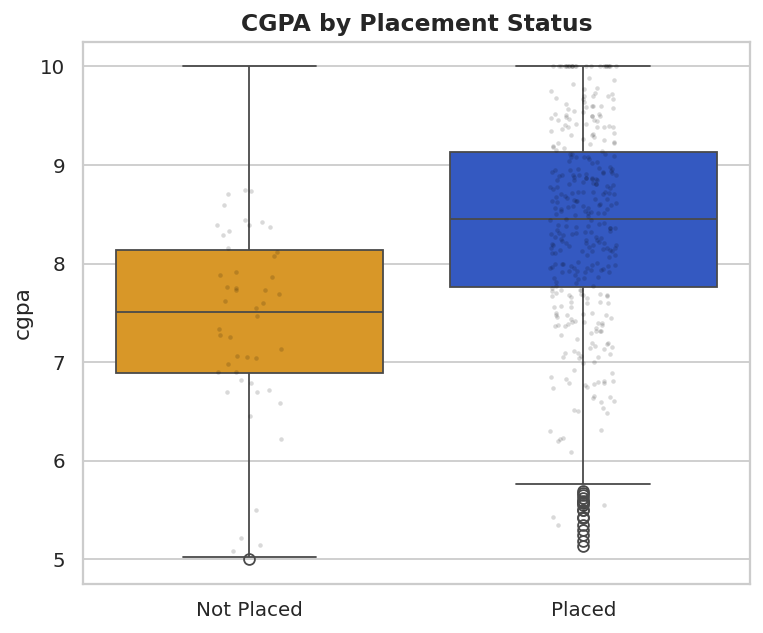

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df_clean, x="placement_label", y="cgpa", order=["Not Placed", "Placed"],
            palette=PALETTE, ax=ax)
sns.stripplot(data=df_clean.sample(min(400, len(df_clean)), random_state=RANDOM_STATE),
              x="placement_label", y="cgpa", order=["Not Placed", "Placed"],
              color="black", alpha=0.15, size=2.5, ax=ax)
ax.set_title("CGPA by Placement Status")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "boxplot_cgpa_placement.png", bbox_inches="tight")
plt.show()

### 5.8 Pairplot of Key Features

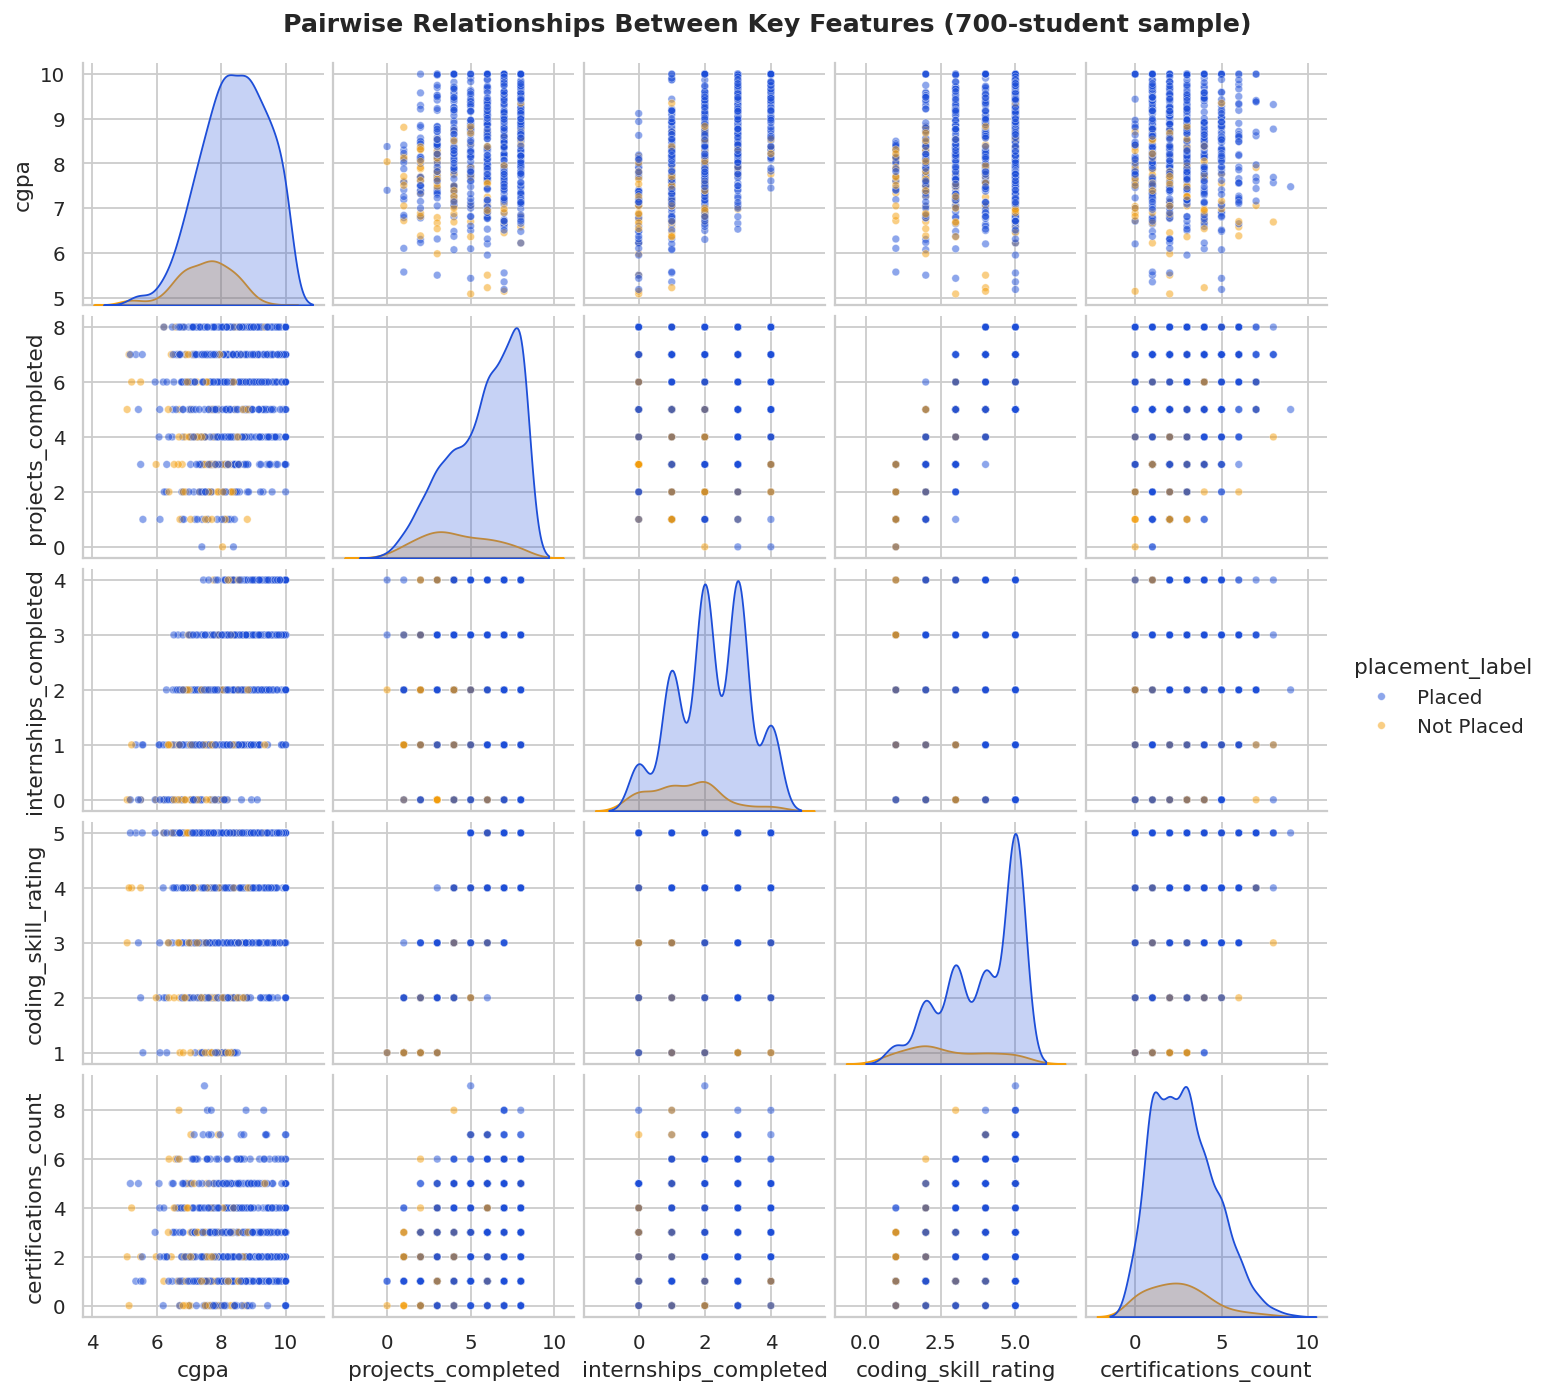

In [20]:
pairplot_cols = ["cgpa", "projects_completed", "internships_completed",
                  "coding_skill_rating", "certifications_count"]
sample_df = df_clean.sample(n=min(700, len(df_clean)), random_state=RANDOM_STATE)

g = sns.pairplot(sample_df, vars=pairplot_cols, hue="placement_label", hue_order=order,
                  palette=PALETTE, plot_kws={"alpha": 0.5, "s": 18}, diag_kind="kde", height=2.1)
g.fig.suptitle("Pairwise Relationships Between Key Features (700-student sample)", y=1.02,
               fontsize=14, fontweight="bold")
g.savefig(REPORTS_DIR / "pairplot.png", bbox_inches="tight")
plt.show()

### 5.9 Bonus: Average Salary by Branch (Placed Students Only)

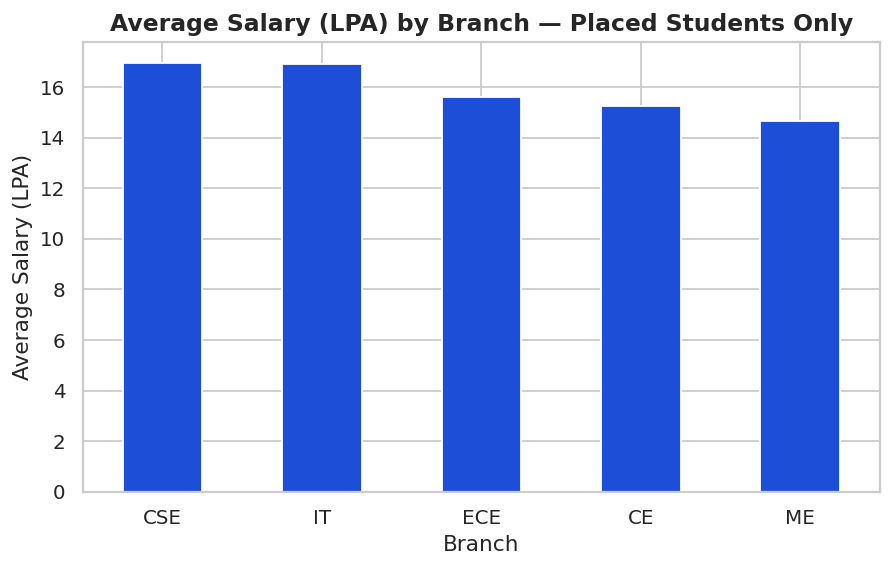

This chart is exploratory only -- salary_lpa is NOT used as a model input (see Section 4).


In [21]:
salary_by_branch = (
    df_clean[df_clean["placement_status"] == 1]
    .groupby("branch")["salary_lpa"].mean()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(7, 4.5))
salary_by_branch.plot(kind="bar", color=ACCENT, ax=ax)
ax.set_title("Average Salary (LPA) by Branch — Placed Students Only")
ax.set_ylabel("Average Salary (LPA)")
ax.set_xlabel("Branch")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "salary_by_branch.png", bbox_inches="tight")
plt.show()
print("This chart is exploratory only -- salary_lpa is NOT used as a model input (see Section 4).")

## 6. Feature Engineering

We derive three composite features that summarise groups of related raw
columns into a single, more interpretable signal:

| New Feature | Formula | Rationale |
|---|---|---|
| `overall_academic_score` | avg(CGPA→%, 10th %, 12th %) | One 0-100 "academic strength" number instead of three separate scores |
| `practical_experience_score` | projects + 2×internships + hackathons | Total hands-on exposure (internships weighted higher — industry-vetted) |
| `soft_skill_index` | avg(communication, aptitude) | A single "non-technical readiness" signal |

These are computed by `PlacementFeatureEngineer`, a small custom
scikit-learn transformer that lives in `utils/feature_engineering.py`
(shared with the Streamlit app) — see Section 10 for why that matters.

In [22]:
demo_engineer = PlacementFeatureEngineer()
df_engineered_preview = demo_engineer.transform(df_clean)

print("New engineered features added:", list(PlacementFeatureEngineer.OUTPUT_COLUMNS))
df_engineered_preview[[
    "cgpa", "tenth_percentage", "twelfth_percentage", "overall_academic_score",
    "projects_completed", "internships_completed", "hackathons_participated", "practical_experience_score",
    "communication_skill_rating", "aptitude_skill_rating", "soft_skill_index",
]].head()

New engineered features added: ['overall_academic_score', 'practical_experience_score', 'soft_skill_index']


,cgpa,tenth_percentage,twelfth_percentage,overall_academic_score,projects_completed,internships_completed,hackathons_participated,practical_experience_score,communication_skill_rating,aptitude_skill_rating,soft_skill_index
0,8.74,74.0,75.0,78.800000,7,3,4,17.0,2,5,3.5
1,7.80,75.3,69.7,74.333333,5,1,4,11.0,4,3,3.5
2,6.95,62.8,68.3,66.866667,8,2,6,18.0,1,4,2.5
3,7.46,57.9,51.4,61.300000,6,2,2,12.0,1,4,2.5
4,6.86,61.3,73.5,67.800000,3,3,2,11.0,5,3,4.0


## 7. Encoding Categorical Variables

Most ML algorithms need numeric input, so text categories (`"Male"`,
`"CSE"`, `"Tier 1"`, ...) must be converted to numbers. We use **One-Hot
Encoding** for every categorical column: each category becomes its own
0/1 column, which avoids implying a false numeric order between categories
that have none (e.g. `branch` has no natural ranking).

The cell below is an **illustration** on the full dataset so you can see
what the transformation looks like. The model itself does *not* use this
copy — see Section 10, where the identical encoding is performed **inside
a pipeline that is fit only on the training split**, so no information
from the test set ever leaks into the transformation.

In [23]:
categorical_features = [
    "gender", "branch", "part_time_job", "family_income_level",
    "city_tier", "internet_access", "extracurricular_involvement",
]
print("Categorical columns and their categories:\n")
for col in categorical_features:
    print(f"- {col}: {sorted(df_clean[col].unique().tolist())}")

illustration_encoded = pd.get_dummies(df_clean[categorical_features], drop_first=True, dtype=int)
print(f"\nShape before encoding: {df_clean[categorical_features].shape}")
print(f"Shape after one-hot encoding (drop_first=True): {illustration_encoded.shape}")
illustration_encoded.head()

Categorical columns and their categories:

- gender: ['Female', 'Male']
- branch: ['CE', 'CSE', 'ECE', 'IT', 'ME']
- part_time_job: ['No', 'Yes']
- family_income_level: ['High', 'Low', 'Medium']
- city_tier: ['Tier 1', 'Tier 2', 'Tier 3']
- internet_access: ['No', 'Yes']
- extracurricular_involvement: ['High', 'Low', 'Medium', 'Unknown']

Shape before encoding: (5000, 7)
Shape after one-hot encoding (drop_first=True): (5000, 14)


,gender_Male,branch_CSE,branch_ECE,branch_IT,branch_ME,part_time_job_Yes,family_income_level_Low,family_income_level_Medium,city_tier_Tier 2,city_tier_Tier 3,internet_access_Yes,extracurricular_involvement_Low,extracurricular_involvement_Medium,extracurricular_involvement_Unknown
0,1,0,1,0,0,1,0,1,1,0,1,0,1,0
1,0,0,1,0,0,1,0,1,0,1,1,1,0,0
2,0,0,0,1,0,0,1,0,1,0,1,0,0,0
3,1,0,1,0,0,0,0,1,0,0,1,1,0,0
4,1,0,0,1,0,0,0,1,0,0,1,0,1,0


## 8. Feature Scaling

Numeric features live on very different scales (CGPA: 5-10, attendance:
45-99%, backlogs: 0-5). Distance- and gradient-based models (KNN, SVM,
Logistic Regression) can end up dominated by whichever feature happens to
have the largest raw numbers unless we rescale everything to a comparable
range. **Standardization** (`StandardScaler`) centers every numeric feature
to mean ≈ 0 and standard deviation ≈ 1.

Again, this is an **illustration** — the real scaling happens inside the
pipeline in Section 10, fit only on the training data.

In [24]:
numeric_features = numeric_cols_raw + list(PlacementFeatureEngineer.OUTPUT_COLUMNS)

illustration_scaler = StandardScaler()
illustration_scaled = pd.DataFrame(
    illustration_scaler.fit_transform(df_engineered_preview[numeric_features]),
    columns=numeric_features,
)

comparison = pd.DataFrame({
    "before_mean": df_engineered_preview[numeric_features].mean(),
    "before_std": df_engineered_preview[numeric_features].std(),
    "after_mean": illustration_scaled.mean(),
    "after_std": illustration_scaled.std(),
}).round(3)
print("Standardization centers every numeric feature to mean~0, std~1, so features")
print("on very different scales contribute fairly to distance-based models.\n")
comparison

Standardization centers every numeric feature to mean~0, std~1, so features
on very different scales contribute fairly to distance-based models.



,before_mean,before_std,after_mean,after_std
cgpa,8.284,1.008,0.0,1.0
tenth_percentage,74.537,10.267,-0.0,1.0
twelfth_percentage,74.543,10.244,0.0,1.0
backlogs,0.344,0.613,0.0,1.0
study_hours_per_day,4.041,1.968,0.0,1.0
attendance_percentage,72.042,7.720,-0.0,1.0
projects_completed,5.529,2.054,0.0,1.0
internships_completed,2.133,1.144,-0.0,1.0
coding_skill_rating,3.729,1.278,-0.0,1.0
communication_skill_rating,3.025,1.412,0.0,1.0


## 9. Train-Test Split

We hold out **20%** of the data for testing and train on the remaining
**80%**, using a *stratified* split so both sets keep the same
Placed / Not-Placed ratio as the full dataset.

Notice that `X` only contains the **raw** columns — the three engineered
features from Section 6 are deliberately *not* added here. They are added
automatically, inside the pipeline, in Section 10.

In [25]:
FEATURE_COLUMNS = numeric_cols_raw + categorical_features   # raw columns only --
                                                              # engineered features are added
                                                              # automatically INSIDE the pipeline
TARGET_COLUMN = "placement_status"

X = df_clean[FEATURE_COLUMNS].copy()
y = df_clean[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} students ({X_train.shape[0] / len(X):.0%})")
print(f"Test set:     {X_test.shape[0]:,} students ({X_test.shape[0] / len(X):.0%})")
print(f"\nTrain set placement rate: {y_train.mean():.1%}")
print(f"Test set placement rate:  {y_test.mean():.1%}")
print("(Stratified split keeps the same Placed/Not-Placed ratio in both sets.)")

Training set: 4,000 students (80%)
Test set:     1,000 students (20%)

Train set placement rate: 86.1%
Test set placement rate:  86.1%
(Stratified split keeps the same Placed/Not-Placed ratio in both sets.)


## 10. Building the Preprocessing + Modeling Pipeline

Everything from Sections 6-8 is now assembled into a single scikit-learn
`Pipeline`:

```
raw student profile  →  PlacementFeatureEngineer  →  ColumnTransformer  →  classifier
                         (Section 6: adds 3 features)  (Section 7+8: encode + scale)
```

**Why bundle all of this into one object instead of doing it as separate
steps?** Two reasons:

1. **No train/test leakage** — when we call `pipeline.fit(X_train, y_train)`,
   the scaler and encoder are fit *only* on the training fold, and reused
   (not re-fit) on the test fold and on every future prediction.
2. **No train/serve skew** — the exact same pipeline object is saved to
   `models/placement_model.pkl` and loaded by the Streamlit app. The app
   never re-implements feature engineering, encoding, or scaling — it just
   calls `pipeline.predict(raw_student_profile)`, so the model always sees
   inputs prepared exactly the way it was trained on.

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

def build_pipeline(model):
    """Wrap any scikit-learn classifier into the full
    feature-engineering -> preprocessing -> model pipeline."""
    return Pipeline(steps=[
        ("feature_engineering", PlacementFeatureEngineer()),
        ("preprocess", preprocessor),
        ("clf", model),
    ])

print("Numeric features (scaled):", numeric_features)
print("\nCategorical features (one-hot encoded):", categorical_features)

Numeric features (scaled): ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 'internships_completed', 'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'stress_level', 'overall_academic_score', 'practical_experience_score', 'soft_skill_index']

Categorical features (one-hot encoded): ['gender', 'branch', 'part_time_job', 'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement']


## 11. Train Multiple Models

We train seven different classification algorithms, each wrapped in the
pipeline built above, using sensible baseline hyperparameters (`class_weight
="balanced"` where supported, since the dataset is imbalanced).

In [27]:
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Support Vector Machine": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained_pipelines = {}
results = []

for name, model in candidate_models.items():
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba),
    }
    results.append(metrics)
    trained_pipelines[name] = pipe
    print(f"Trained {name:<24s} | Accuracy: {metrics['Accuracy']:.3f} | "
          f"F1: {metrics['F1 Score']:.3f} | ROC AUC: {metrics['ROC AUC']:.3f}")

print("\nAll 7 models trained successfully.")

Trained Logistic Regression      | Accuracy: 0.827 | F1: 0.891 | ROC AUC: 0.910


Trained Decision Tree            | Accuracy: 0.842 | F1: 0.908 | ROC AUC: 0.670

Trained Random Forest            | Accuracy: 0.887 | F1: 0.937 | ROC AUC: 0.898
Trained K-Nearest Neighbors      | Accuracy: 0.871 | F1: 0.928 | ROC AUC: 0.823


Trained Support Vector Machine   | Accuracy: 0.832 | F1: 0.895 | ROC AUC: 0.888
Trained Naive Bayes              | Accuracy: 0.813 | F1: 0.882 | ROC AUC: 0.881


Trained Gradient Boosting        | Accuracy: 0.884 | F1: 0.934 | ROC AUC: 0.906

All 7 models trained successfully.


## 12. Model Comparison

We compare all seven models side by side across five metrics: Accuracy,
Precision, Recall, F1 Score, and ROC AUC.

In [28]:
comparison_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
comparison_df_display = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]:
    comparison_df_display[col] = comparison_df_display[col].round(4)

comparison_df_display.style.background_gradient(
    cmap="Blues", subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.887000,0.895300,0.983700,0.937500,0.897800
1,Gradient Boosting,0.884000,0.912500,0.957000,0.934200,0.905900
2,K-Nearest Neighbors,0.871000,0.893500,0.965200,0.928000,0.823400
3,Decision Tree,0.842000,0.908200,0.908200,0.908200,0.670000
4,Support Vector Machine,0.832000,0.968900,0.831600,0.895000,0.887700
5,Logistic Regression,0.827000,0.971200,0.823500,0.891300,0.910500
6,Naive Bayes,0.813000,0.964200,0.813000,0.882200,0.880700


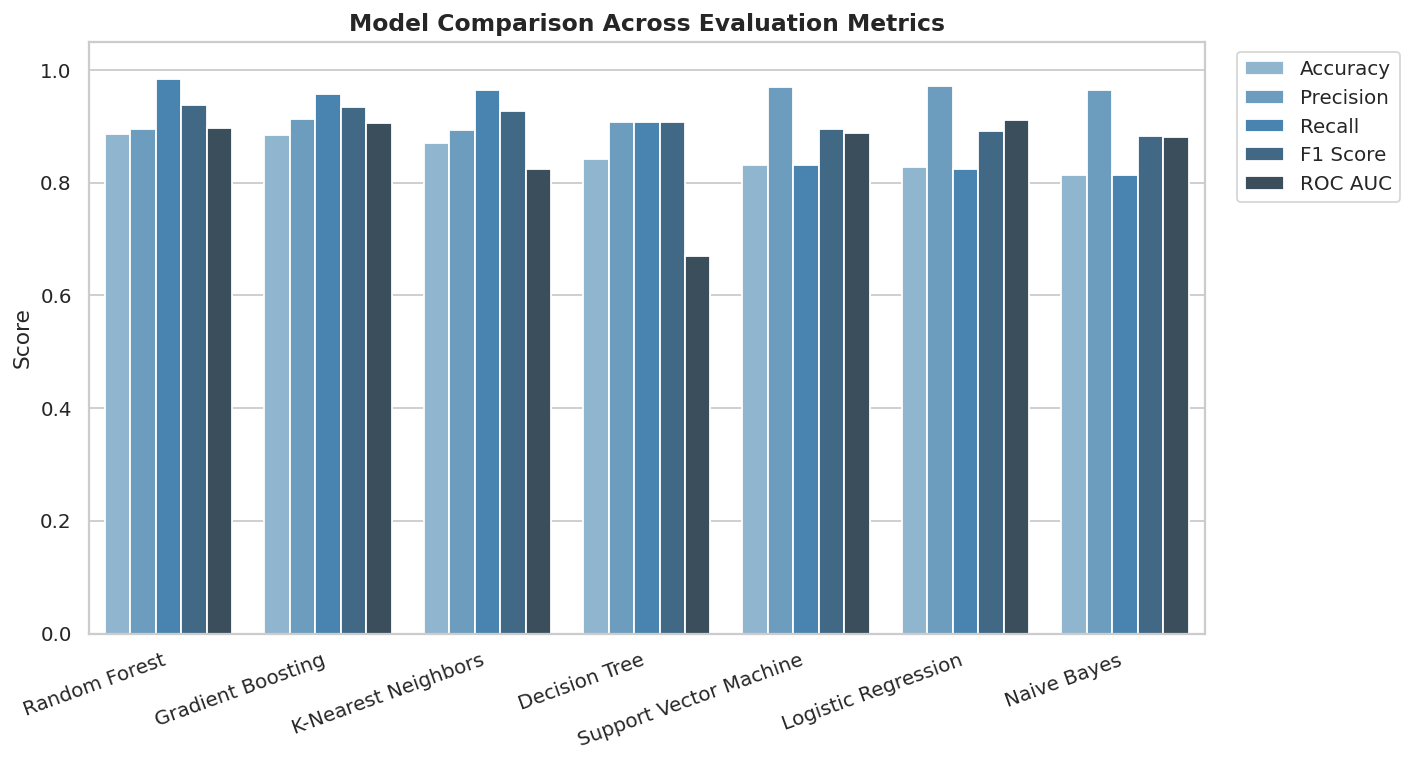

In [29]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = comparison_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
                               var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", ax=ax, palette="Blues_d")
ax.set_title("Model Comparison Across Evaluation Metrics")
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

## 13. Select Best Model

We rank models by **F1 Score** rather than plain Accuracy, because the
dataset is imbalanced (~86% Placed). F1 balances Precision and Recall, so a
model cannot score well just by always predicting the majority class the
way it could with Accuracy alone.

In [30]:
BEST_MODEL_NAME = comparison_df.iloc[0]["Model"]
best_baseline_pipeline = trained_pipelines[BEST_MODEL_NAME]

print(f"Best baseline model (by F1 Score): {BEST_MODEL_NAME}")
print(comparison_df[comparison_df["Model"] == BEST_MODEL_NAME].to_string(index=False))
print(
    "\nWe select by F1 Score because the dataset is imbalanced (~86% Placed). "
    "F1 balances Precision and Recall, so a model cannot score well just by "
    "always predicting the majority class."
)

Best baseline model (by F1 Score): Random Forest
        Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
Random Forest     0.887   0.895349 0.98374  0.937465 0.897785

We select by F1 Score because the dataset is imbalanced (~86% Placed). F1 balances Precision and Recall, so a model cannot score well just by always predicting the majority class.


## 14. Hyperparameter Tuning

We run a `GridSearchCV` (5-fold, scored on F1) over a parameter grid tailored
to whichever model won Section 13, to see if we can improve on its baseline
settings. A grid is defined for every candidate model so this cell works
automatically no matter which one comes out on top.

In [31]:
param_grids = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10], "clf__solver": ["lbfgs"]},
    "Decision Tree": {"clf__max_depth": [3, 5, 7, 10, None], "clf__min_samples_split": [2, 5, 10],
                      "clf__min_samples_leaf": [1, 2, 4]},
    "Random Forest": {"clf__n_estimators": [150, 250, 350], "clf__max_depth": [6, 10, 16, None],
                       "clf__min_samples_leaf": [1, 2, 4]},
    "K-Nearest Neighbors": {"clf__n_neighbors": [3, 5, 7, 9, 11, 15], "clf__weights": ["uniform", "distance"]},
    "Support Vector Machine": {"clf__C": [0.5, 1, 5, 10], "clf__kernel": ["rbf", "linear"]},
    "Naive Bayes": {"clf__var_smoothing": np.logspace(0, -9, 10)},
    "Gradient Boosting": {"clf__n_estimators": [100, 200, 300], "clf__learning_rate": [0.01, 0.05, 0.1],
                           "clf__max_depth": [2, 3, 4]},
}

grid = GridSearchCV(
    estimator=build_pipeline(candidate_models[BEST_MODEL_NAME]),
    param_grid=param_grids[BEST_MODEL_NAME],
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print(f"Best cross-validated F1 score during tuning: {grid.best_score_:.4f}")
print("Best hyperparameters found:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

tuned_pipeline = grid.best_estimator_

Best cross-validated F1 score during tuning: 0.9357
Best hyperparameters found:
  clf__max_depth: None
  clf__min_samples_leaf: 2
  clf__n_estimators: 250


In [32]:
def evaluate_pipeline(pipe, X_eval, y_eval):
    y_pred = pipe.predict(X_eval)
    y_proba = pipe.predict_proba(X_eval)[:, 1]
    return {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1 Score": f1_score(y_eval, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_eval, y_proba),
    }

baseline_metrics = evaluate_pipeline(best_baseline_pipeline, X_test, y_test)
tuned_metrics = evaluate_pipeline(tuned_pipeline, X_test, y_test)

before_after = pd.DataFrame([baseline_metrics, tuned_metrics], index=["Baseline", "Tuned"]).round(4)
print(before_after)

if tuned_metrics["F1 Score"] >= baseline_metrics["F1 Score"]:
    final_pipeline = tuned_pipeline
    FINAL_MODEL_SOURCE = "tuned"
else:
    final_pipeline = best_baseline_pipeline
    FINAL_MODEL_SOURCE = "baseline"

print(f"\nFinal model selected: {BEST_MODEL_NAME} ({FINAL_MODEL_SOURCE} hyperparameters)")

          Accuracy  Precision  Recall  F1 Score  ROC AUC
Baseline     0.887     0.8953  0.9837    0.9375   0.8978
Tuned        0.897     0.9138  0.9721    0.9420   0.9000

Final model selected: Random Forest (tuned hyperparameters)


## 15. Confusion Matrix

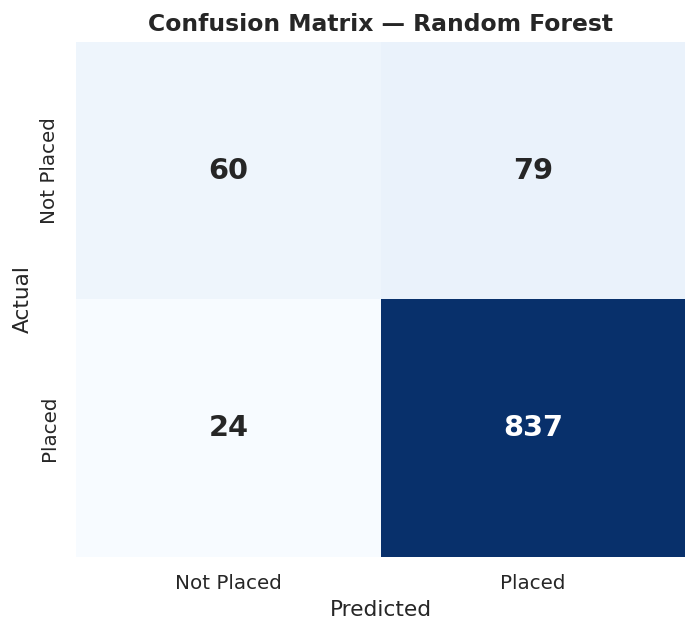

True Negatives  (correctly predicted Not Placed): 60
False Positives (predicted Placed, actually Not Placed): 79
False Negatives (predicted Not Placed, actually Placed): 24
True Positives  (correctly predicted Placed): 837


In [33]:
y_pred_final = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Placed", "Placed"], yticklabels=["Not Placed", "Placed"], ax=ax,
            annot_kws={"size": 16, "weight": "bold"})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted Not Placed): {tn}")
print(f"False Positives (predicted Placed, actually Not Placed): {fp}")
print(f"False Negatives (predicted Not Placed, actually Placed): {fn}")
print(f"True Positives  (correctly predicted Placed): {tp}")

## 16. ROC Curve

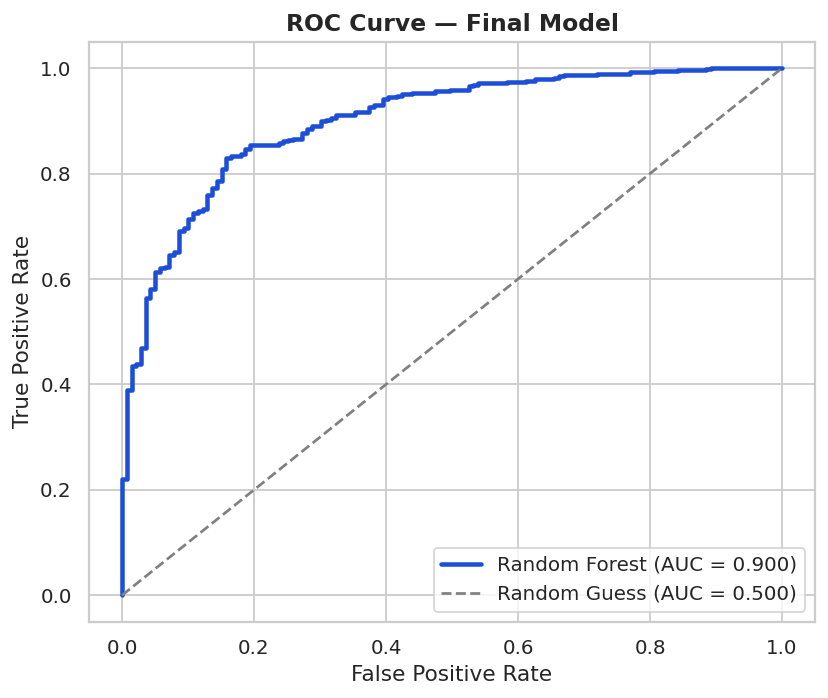

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
auc_score = roc_auc_score(y_test, y_proba_final)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr, tpr, color=ACCENT, linewidth=2.5, label=f"{BEST_MODEL_NAME} (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Final Model")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "roc_curve.png", bbox_inches="tight")
plt.show()

## 17. Classification Report

In [35]:
report_text = classification_report(y_test, y_pred_final, target_names=["Not Placed", "Placed"])
print(report_text)

report_dict = classification_report(y_test, y_pred_final, target_names=["Not Placed", "Placed"], output_dict=True)

              precision    recall  f1-score   support

  Not Placed       0.71      0.43      0.54       139
      Placed       0.91      0.97      0.94       861

    accuracy                           0.90      1000
   macro avg       0.81      0.70      0.74      1000
weighted avg       0.89      0.90      0.89      1000



## 18. Cross-Validation

A single train/test split can be lucky or unlucky. 5-fold cross-validation
re-fits the entire pipeline five times on different splits of the *whole*
dataset and reports the spread of scores, giving a more robust estimate of
how the model performs on unseen data.

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1_scores = cross_val_score(final_pipeline, X, y, cv=cv, scoring="f1", n_jobs=-1)
cv_acc_scores = cross_val_score(final_pipeline, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

print("5-Fold Cross-Validation (entire dataset, final pipeline re-fit on each fold):")
print(f"  F1 Score:  {cv_f1_scores.round(4)} -> mean {cv_f1_scores.mean():.4f} +/- {cv_f1_scores.std():.4f}")
print(f"  Accuracy:  {cv_acc_scores.round(4)} -> mean {cv_acc_scores.mean():.4f} +/- {cv_acc_scores.std():.4f}")
print("\nConsistent scores across folds indicate the model generalises well and isn't overfit to one split.")

5-Fold Cross-Validation (entire dataset, final pipeline re-fit on each fold):
  F1 Score:  [0.933  0.9369 0.9422 0.9336 0.9353] -> mean 0.9362 +/- 0.0033
  Accuracy:  [0.881 0.888 0.897 0.882 0.886] -> mean 0.8868 +/- 0.0057

Consistent scores across folds indicate the model generalises well and isn't overfit to one split.


## 19. Feature Importance

We use **permutation importance**: each raw feature is randomly shuffled
(one at a time) and we measure how much the model's F1 score drops. A big
drop means the model relies heavily on that feature. This method works for
*any* model type (not just tree-based ones), and it is measured on the raw
input columns — exactly the columns a user fills in on the Direct
Prediction page — which makes it directly usable for generating
personalised improvement suggestions in the app.

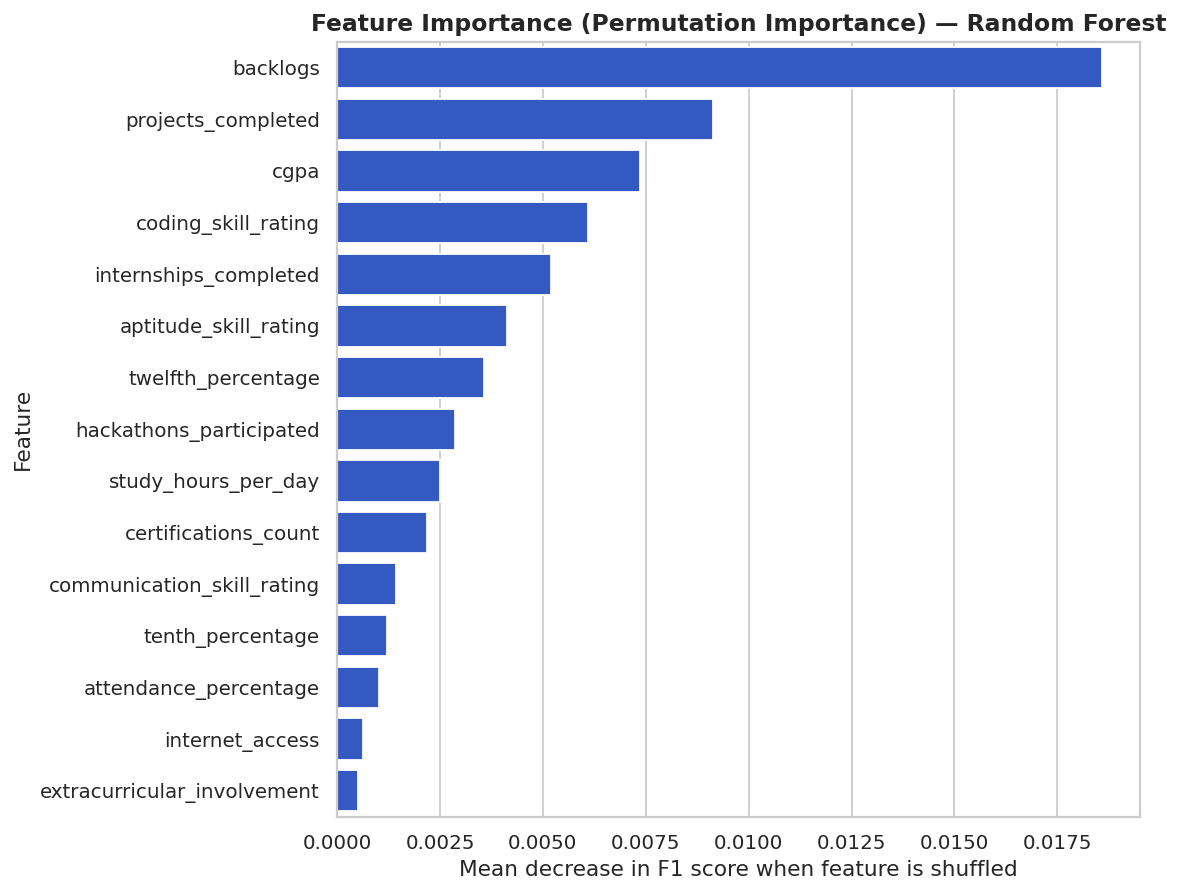

,Feature,Importance,Std
0,backlogs,0.018584,0.002772
1,projects_completed,0.009138,0.002902
2,cgpa,0.007359,0.002106
3,coding_skill_rating,0.006105,0.001788
4,internships_completed,0.005192,0.002230
5,aptitude_skill_rating,0.004126,0.000965
6,twelfth_percentage,0.003561,0.001922
7,hackathons_participated,0.002868,0.001927
8,study_hours_per_day,0.002501,0.001466
9,certifications_count,0.002175,0.001246


In [37]:
perm_result = permutation_importance(
    final_pipeline, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring="f1", n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
top_n = importance_df.head(15)
sns.barplot(data=top_n, y="Feature", x="Importance", color=ACCENT, ax=ax)
ax.set_title(f"Feature Importance (Permutation Importance) — {BEST_MODEL_NAME}")
ax.set_xlabel("Mean decrease in F1 score when feature is shuffled")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()

importance_df.head(10)

## 20. Save the Final Model & Supporting Artifacts

Three files are exported to `models/` for the Streamlit app to consume:

- **`placement_model.pkl`** — the complete, fitted pipeline (feature
  engineering + encoding + scaling + classifier) — the app calls
  `.predict()` / `.predict_proba()` directly on raw student-profile input.
- **`feature_config.json`** — feature lists, valid category options, numeric
  ranges/defaults (used to build the app's input forms), and per-cohort
  statistics (used to generate personalised improvement suggestions).
- **`model_metrics.json`** — every metric, chart data series, and table
  computed above, so the app's *Model Performance* page can display them
  without re-running any training code.

In [38]:
placed_df = df_clean[df_clean["placement_status"] == 1]
not_placed_df = df_clean[df_clean["placement_status"] == 0]

def cohort_stats(frame, cols):
    return {
        col: {
            "mean": round(float(frame[col].mean()), 3),
            "median": round(float(frame[col].median()), 3),
            "p25": round(float(frame[col].quantile(0.25)), 3),
            "p75": round(float(frame[col].quantile(0.75)), 3),
        }
        for col in cols
    }

numeric_ranges = {col: [float(df_clean[col].min()), float(df_clean[col].max())] for col in numeric_cols_raw}
numeric_defaults = {col: round(float(df_clean[col].median()), 2) for col in numeric_cols_raw}
categorical_options = {col: sorted(df_clean[col].unique().tolist()) for col in categorical_features}
categorical_defaults = {col: df_clean[col].mode().iloc[0] for col in categorical_features}

feature_config = {
    "numeric_features": numeric_cols_raw,
    "categorical_features": categorical_features,
    "engineered_features": list(PlacementFeatureEngineer.OUTPUT_COLUMNS),
    "target_map": {"Not Placed": 0, "Placed": 1},
    "numeric_ranges": numeric_ranges,
    "numeric_defaults": numeric_defaults,
    "categorical_options": categorical_options,
    "categorical_defaults": categorical_defaults,
    "placed_cohort_stats": cohort_stats(placed_df, numeric_cols_raw),
    "not_placed_cohort_stats": cohort_stats(not_placed_df, numeric_cols_raw),
    "dataset_shape": list(df.shape),
    "class_balance": {
        "placed_pct": round(float(status_pct["Placed"]), 2),
        "not_placed_pct": round(float(status_pct["Not Placed"]), 2),
    },
}

with open(MODELS_DIR / "feature_config.json", "w") as f:
    json.dump(to_serializable(feature_config), f, indent=2)

print("Saved models/feature_config.json")

Saved models/feature_config.json


In [39]:
final_test_metrics = tuned_metrics if FINAL_MODEL_SOURCE == "tuned" else baseline_metrics

model_metrics = {
    "best_model_name": BEST_MODEL_NAME,
    "final_model_source": FINAL_MODEL_SOURCE,
    "comparison_table": comparison_df.round(4).to_dict(orient="records"),
    "tuning": {
        "best_cv_f1": grid.best_score_,
        "best_params": grid.best_params_,
    },
    "test_metrics": final_test_metrics,
    "confusion_matrix": cm.tolist(),
    "classification_report": report_dict,
    "roc_curve": {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "auc": auc_score},
    "cross_validation": {
        "f1_scores": cv_f1_scores.tolist(),
        "f1_mean": cv_f1_scores.mean(),
        "f1_std": cv_f1_scores.std(),
        "accuracy_scores": cv_acc_scores.tolist(),
        "accuracy_mean": cv_acc_scores.mean(),
        "accuracy_std": cv_acc_scores.std(),
    },
    "feature_importance": importance_df.round(4).to_dict(orient="records"),
    "train_test_split": {
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_fraction": 0.2,
    },
}

with open(MODELS_DIR / "model_metrics.json", "w") as f:
    json.dump(to_serializable(model_metrics), f, indent=2)

print("Saved models/model_metrics.json")

Saved models/model_metrics.json


In [40]:
MODEL_PATH = MODELS_DIR / "placement_model.pkl"
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Saved final model pipeline to: {MODEL_PATH.resolve()}")
print(f"Model file size: {MODEL_PATH.stat().st_size / 1024:.1f} KB")

Saved final model pipeline to: /home/claude/build/placement-ai-suite/models/placement_model.pkl
Model file size: 12670.0 KB


## 21. Sanity Check — Predict a Sample Student

As a final integrity check, we reload the saved `.pkl` from disk (exactly
as the Streamlit app does) and run a prediction on a made-up student
profile, using only raw, human-entered values.

In [41]:
sample_student = pd.DataFrame([{
    "cgpa": 8.6, "tenth_percentage": 88.0, "twelfth_percentage": 85.0, "backlogs": 0,
    "study_hours_per_day": 5.5, "attendance_percentage": 82.0, "projects_completed": 6,
    "internships_completed": 2, "coding_skill_rating": 4, "communication_skill_rating": 4,
    "aptitude_skill_rating": 4, "hackathons_participated": 3, "certifications_count": 4,
    "sleep_hours": 7.0, "stress_level": 5, "gender": "Female", "branch": "CSE",
    "part_time_job": "No", "family_income_level": "Medium", "city_tier": "Tier 1",
    "internet_access": "Yes", "extracurricular_involvement": "High",
}])

reloaded_pipeline = joblib.load(MODEL_PATH)
pred = reloaded_pipeline.predict(sample_student)[0]
proba = reloaded_pipeline.predict_proba(sample_student)[0]

print("Sample student profile:")
print(sample_student.T)
print(f"\nPredicted status: {'PLACED' if pred == 1 else 'NOT PLACED'}")
print(f"Confidence -> Placed: {proba[1]:.1%}  |  Not Placed: {proba[0]:.1%}")
print("\nThe saved pipeline loaded fresh and produced a prediction directly from raw,")
print("human-entered feature values -- exactly how the Streamlit app will call it.")

Sample student profile:
                                  0
cgpa                            8.6
tenth_percentage               88.0
twelfth_percentage             85.0
backlogs                          0
study_hours_per_day             5.5
attendance_percentage          82.0
projects_completed                6
internships_completed             2
coding_skill_rating               4
communication_skill_rating        4
aptitude_skill_rating             4
hackathons_participated           3
certifications_count              4
sleep_hours                     7.0
stress_level                      5
gender                       Female
branch                          CSE
part_time_job                    No
family_income_level          Medium
city_tier                    Tier 1
internet_access                 Yes
extracurricular_involvement    High

Predicted status: PLACED
Confidence -> Placed: 99.3%  |  Not Placed: 0.7%

The saved pipeline loaded fresh and produced a prediction directly from 

## 22. Conclusion

In [42]:
top_features = importance_df.head(5)["Feature"].tolist()

conclusion = f"""
FINAL MODEL: {BEST_MODEL_NAME} ({FINAL_MODEL_SOURCE} hyperparameters)

Why this model was selected
----------------------------
Among all 7 candidate algorithms, {BEST_MODEL_NAME} achieved the highest
F1 Score ({comparison_df.iloc[0]['F1 Score']:.4f}) on the held-out test set.
F1 was chosen as the primary metric (over plain Accuracy) because of the
~{status_pct['Placed']:.0f}% / {status_pct['Not Placed']:.0f}% class imbalance
between Placed and Not Placed students.

Final held-out test performance
--------------------------------
  Accuracy:  {final_test_metrics['Accuracy']:.4f}
  Precision: {final_test_metrics['Precision']:.4f}
  Recall:    {final_test_metrics['Recall']:.4f}
  F1 Score:  {final_test_metrics['F1 Score']:.4f}
  ROC AUC:   {final_test_metrics['ROC AUC']:.4f}

5-fold cross-validation F1 (whole dataset): {cv_f1_scores.mean():.4f} +/- {cv_f1_scores.std():.4f}
  -> Consistent scores across folds suggest the model generalises well
     rather than overfitting to a single train/test split.

Top 5 most influential features (by permutation importance)
-------------------------------------------------------------
  {', '.join(top_features)}

Limitations & future improvements
------------------------------------
  - The dataset is a structured/aggregated dataset and may not capture every
    real-world hiring factor (interview performance, specific company
    requirements, referrals, or economic conditions in a given placement season).
  - `extracurricular_involvement` was missing for ~20% of students; those rows
    were kept with an explicit "Unknown" category rather than dropped or guessed.
  - Future work could add recruiter-side features (company type, role),
    placement-season time trends, and richer resume-derived signals (project
    descriptions, GitHub activity) rather than single 1-5 skill ratings.
"""
print(conclusion)


FINAL MODEL: Random Forest (tuned hyperparameters)

Why this model was selected
----------------------------
Among all 7 candidate algorithms, Random Forest achieved the highest
F1 Score (0.9375) on the held-out test set.
F1 was chosen as the primary metric (over plain Accuracy) because of the
~86% / 14% class imbalance
between Placed and Not Placed students.

Final held-out test performance
--------------------------------
  Accuracy:  0.8970
  Precision: 0.9138
  Recall:    0.9721
  F1 Score:  0.9420
  ROC AUC:   0.9000

5-fold cross-validation F1 (whole dataset): 0.9362 +/- 0.0033
  -> Consistent scores across folds suggest the model generalises well
     rather than overfitting to a single train/test split.

Top 5 most influential features (by permutation importance)
-------------------------------------------------------------
  backlogs, projects_completed, cgpa, coding_skill_rating, internships_completed

Limitations & future improvements
------------------------------------
  

---
### Appendix: How the Streamlit App Uses These Artifacts

| File | Used by | Purpose |
|---|---|---|
| `models/placement_model.pkl` | `utils/model_utils.py` | `pipeline.predict_proba(raw_profile_df)` → placement probability |
| `models/feature_config.json` | Direct Prediction & Resume Analyzer pages | Slider ranges, dropdown options, defaults, cohort stats for suggestions |
| `models/model_metrics.json` | Model Performance page | Renders the comparison table, confusion matrix, ROC curve, feature importance |
| `reports/*.png` | Model Performance page & your project report | Ready-to-screenshot professional charts |

**To retrain with new or updated data:** replace `data/placement_data.csv`
and re-run this notebook (`Kernel → Restart & Run All`). The Streamlit app
will automatically pick up the newly saved artifacts next time it starts.